# Week 3 Lab: Train, diagnose and evaluate a GAN

**Module:** Generative AI (MSc in Artificial Intelligence) · **Time:** 2 hours · **Learning outcomes:** MIMLO 1, 3, 4

You will implement a **DCGAN** in PyTorch, train it on MNIST, and then act like a researcher:

1. implement the **discriminator** and **non-saturating generator** losses;
2. watch samples evolve across epochs and read the training diagnostics;
3. explore the latent space with linear and **spherical** interpolation;
4. **evaluate** the generator: mode coverage with a digit classifier and a Fréchet distance you implement;
5. see **mode collapse** on a 2-D toy problem and fix it with **WGAN-GP**.

| Part | Topic | Suggested time |
|---|---|---|
| 0–1 | Setup, data, models | 15 min |
| 2 | Losses and training | 30 min |
| 3 | Latent space | 10 min |
| 4 | Evaluation (coverage + Fréchet distance) | 30 min |
| 5 | Mode collapse and WGAN-GP | 25 min |
| 6 | Reflection | 10 min |

> **INSTRUCTOR VERSION — contains solutions. Do not distribute before the lab.**

> **How to run this notebook**
> - **Google Colab (recommended):** File ▸ Upload notebook, then Runtime ▸ Change runtime type ▸ **T4 GPU**. Run cells top to bottom with Shift+Enter.
> - **Local Jupyter / VS Code:** Python 3.10+; run the install cell once. A GPU is optional: every cell has a CPU-friendly setting.
> - **API keys (optional cells only):** store keys in Colab ▸ 🔑 Secrets or an environment variable. Never paste a key into a notebook you share.
> - Cells marked **TODO** are yours to complete. Questions marked ✍️ need a short written answer.

## Before coding: two networks, two training roles

A **generator** turns random codes into images. A **discriminator** learns to
distinguish those images from real data. They improve through alternating
updates; an individual code has no corresponding target training digit.

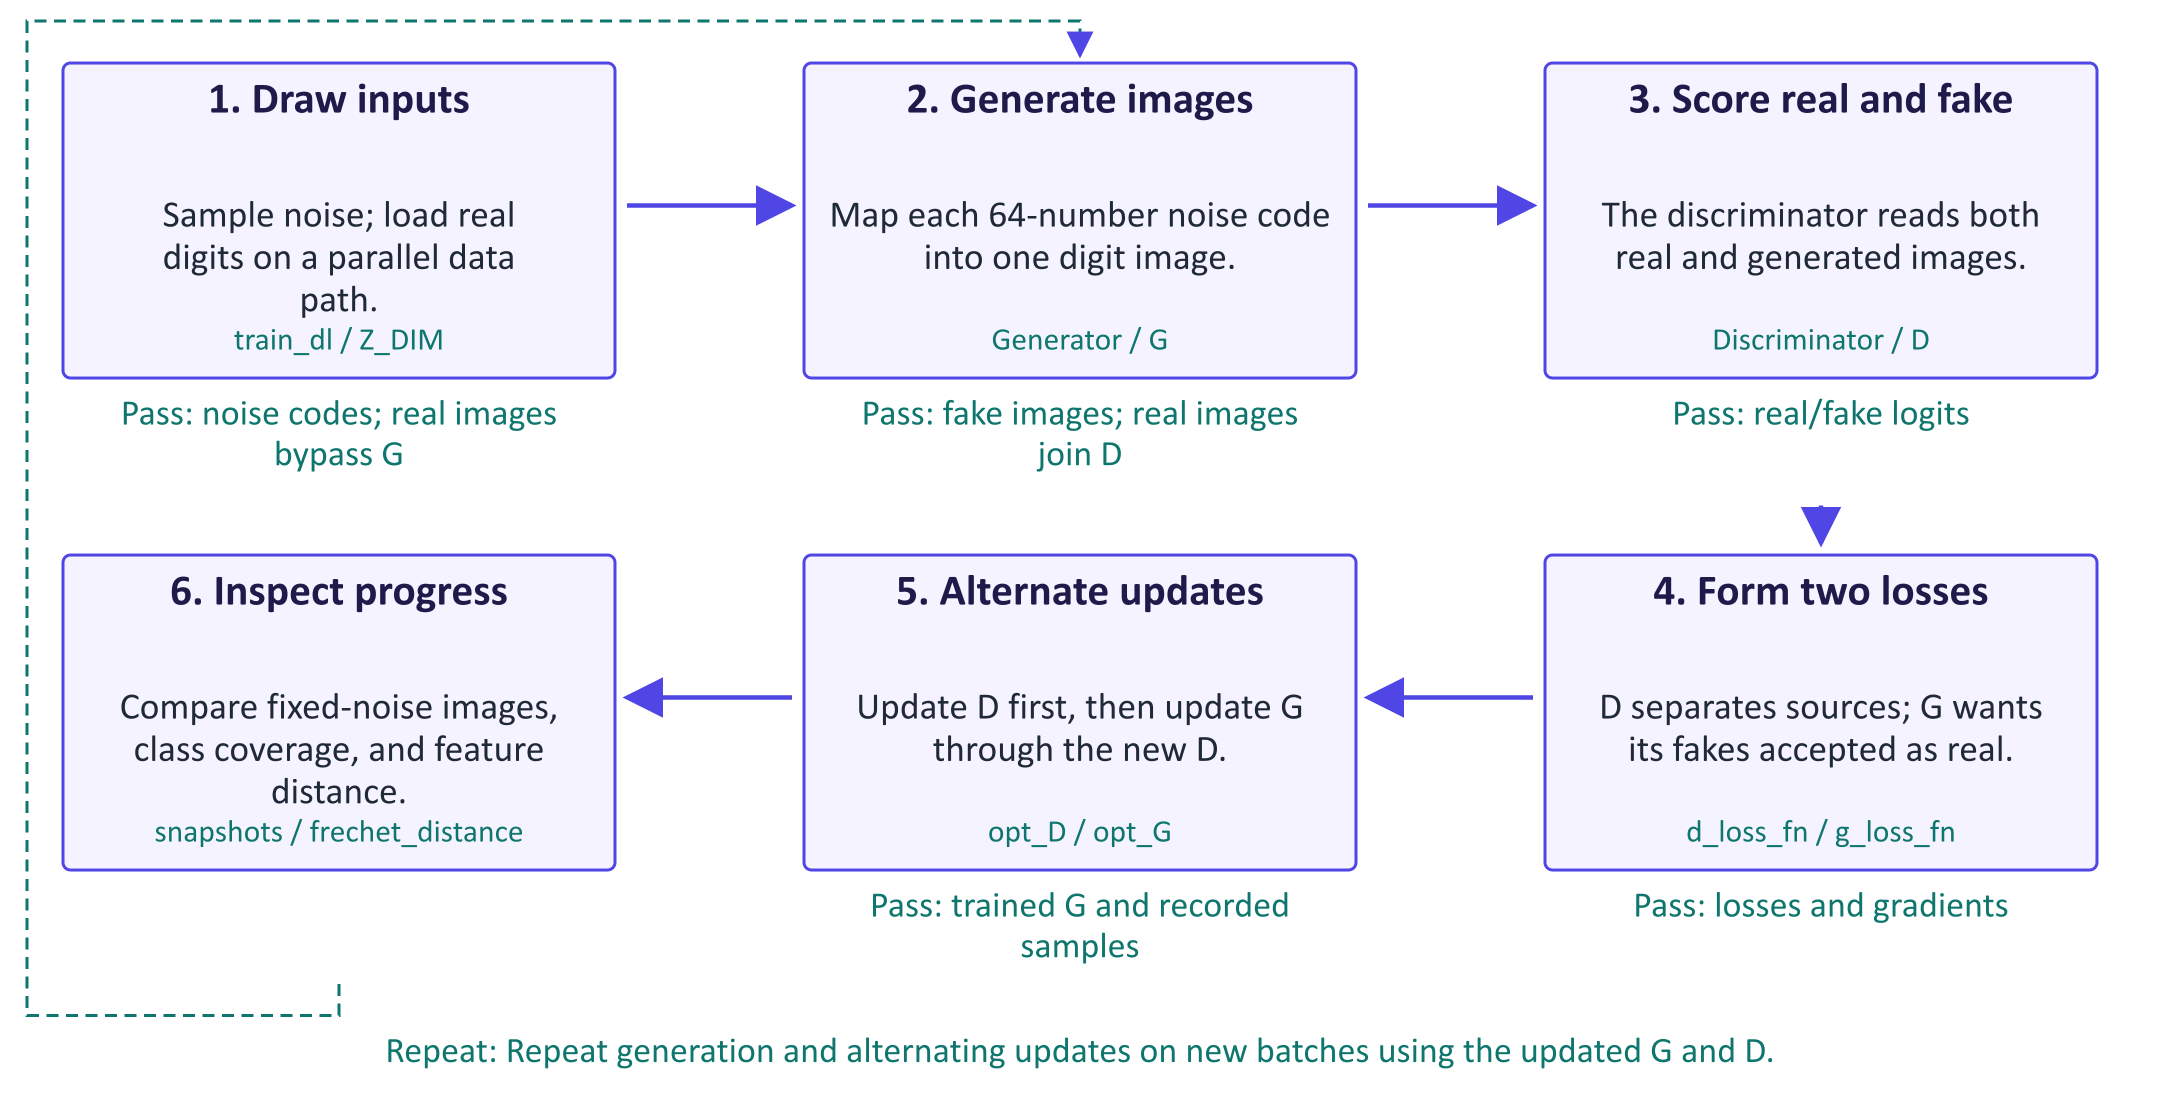

Follow the noise path into `G` and the real-image path directly into `D`.
`d_loss_fn` trains `D` to distinguish sources. `g_loss_fn` sends feedback
through `D` to `G`. After training, generation uses `G` alone.

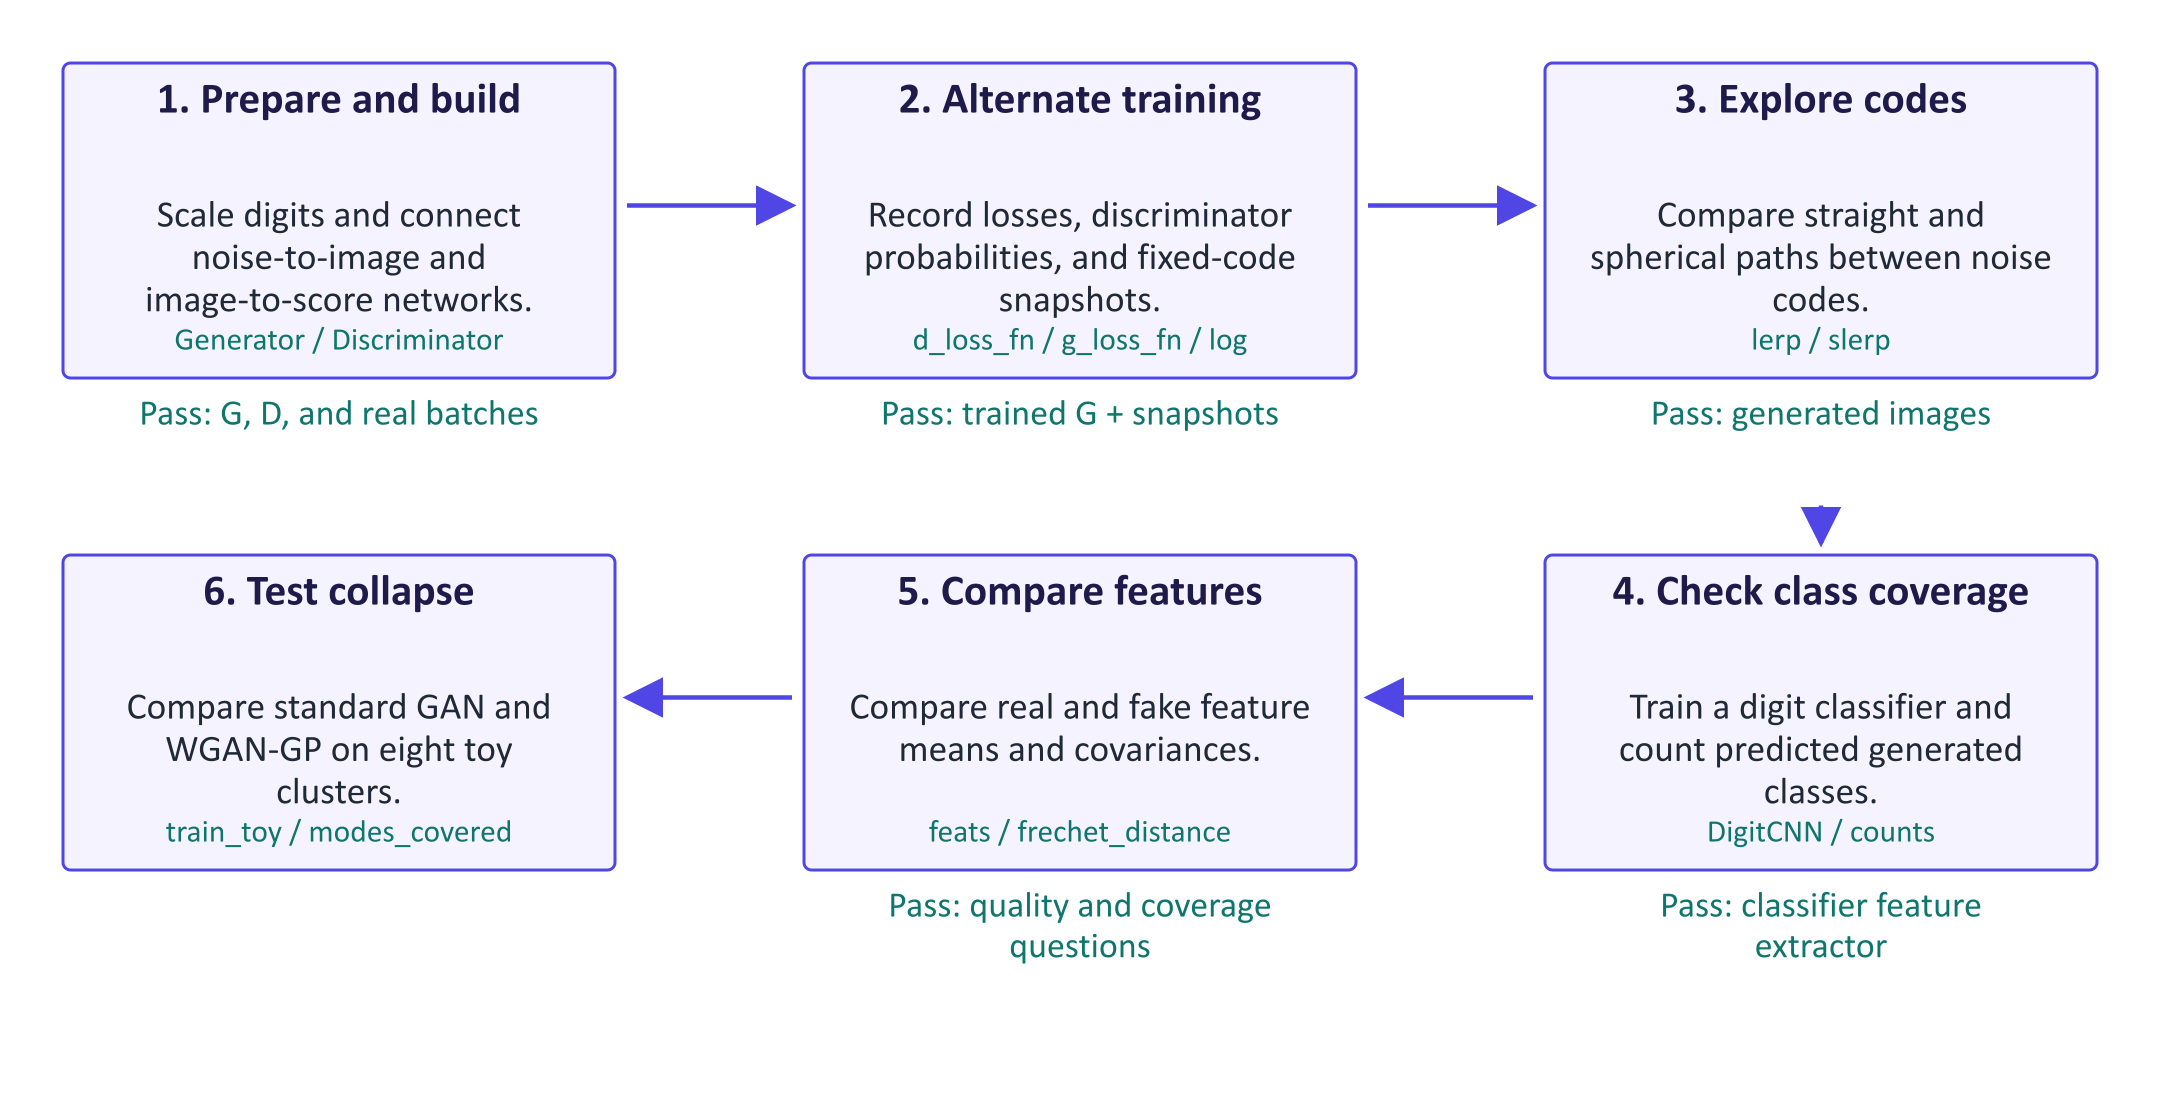

| Diagram block | Code to find | First observation |
|---|---|---|
| Prepare and build | `Generator`, `Discriminator` | Noise has 64 values; each image is 28 by 28 pixels. |
| Alternate training | `d_loss_fn`, `g_loss_fn`, `log` | The same fakes have different target roles in the two updates. |
| Explore codes | `lerp`, `slerp` | Compare images and code norms along each path. |
| Check class coverage | `DigitCNN`, `counts` | Classifier errors affect the estimated histogram. |
| Compare features | `feats`, `frechet_distance` | This score uses the lab's classifier features. |
| Test collapse | `train_toy`, `modes_covered` | Count coverage as well as inspecting the scatter plots. |

**Pause and predict:** should the generator receive gradients when the
discriminator learns to reject its fakes? Trace each update separately.

In [ ]:
%pip install -q torch torchvision scipy matplotlib

In [ ]:
import copy
import os

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

SMOKE = os.environ.get("GENAI_LAB_SMOKE") == "1"
torch.manual_seed(0)
np.random.seed(0)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
EPOCHS = 1 if SMOKE else 8
Z_DIM = 64
print("device:", DEVICE, "| epochs:", EPOCHS)

## Part 1 · Data and models
GAN generators usually end with `tanh`, so we scale pixels to **[−1, 1]**.

In [ ]:
tf = transforms.Compose([transforms.ToTensor(), transforms.Normalize([0.5], [0.5])])
train_set = datasets.MNIST("data", train=True, download=True, transform=tf)
test_set = datasets.MNIST("data", train=False, download=True, transform=tf)
if SMOKE:
    train_set = Subset(train_set, range(3000))
train_dl = DataLoader(train_set, batch_size=128, shuffle=True, drop_last=True)


def show(imgs, n=16, title=None):
    imgs = imgs[:n].detach().cpu()
    plt.figure(figsize=(n * 0.6, 0.9))
    plt.imshow(np.hstack(((imgs[:, 0] + 1) / 2).numpy()), cmap="gray_r", vmin=0, vmax=1)
    plt.axis("off")
    if title:
        plt.title(title, loc="left")
    plt.show()


show(next(iter(train_dl))[0], title="Real MNIST digits")

The DCGAN generator upsamples a noise vector with **transposed convolutions**; the discriminator is a small CNN that outputs one **logit** (real vs. fake).

**Read the shapes:** G maps `[B, 64]` codes to `[B, 1, 28, 28]` images.
D maps those images to `[B]` scores. A logit is a score, not a probability;
the diagnostics apply sigmoid when showing D(real) and D(fake).

In [ ]:
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.ConvTranspose2d(Z_DIM, 128, 7, 1, 0, bias=False), nn.BatchNorm2d(128), nn.ReLU(True),  # 7x7
            nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False), nn.BatchNorm2d(64), nn.ReLU(True),     # 14x14
            nn.ConvTranspose2d(64, 1, 4, 2, 1, bias=False), nn.Tanh())                               # 28x28

    def forward(self, z):
        return self.net(z.view(-1, Z_DIM, 1, 1))


class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 64, 4, 2, 1), nn.LeakyReLU(0.2, True),
            nn.Conv2d(64, 128, 4, 2, 1, bias=False), nn.BatchNorm2d(128), nn.LeakyReLU(0.2, True),
            nn.Conv2d(128, 1, 7, 1, 0))

    def forward(self, x):
        return self.net(x).view(-1)


def init_weights(m):  # DCGAN initialisation
    if isinstance(m, (nn.Conv2d, nn.ConvTranspose2d)):
        nn.init.normal_(m.weight, 0.0, 0.02)
    elif isinstance(m, nn.BatchNorm2d):
        nn.init.normal_(m.weight, 1.0, 0.02)
        nn.init.zeros_(m.bias)


G, D = Generator().to(DEVICE), Discriminator().to(DEVICE)
G.apply(init_weights)
D.apply(init_weights)
print(f"G: {sum(p.numel() for p in G.parameters()):,} parameters | D: {sum(p.numel() for p in D.parameters()):,} parameters")

## Part 2 · Losses and training

`bce = nn.BCEWithLogitsLoss()` expects logits and targets (1 = real, 0 = fake).

**TODO 1 (discriminator loss):** real images should be classified as 1 and generated images as 0. Remember to **detach** the fakes so this step does not update G.

**TODO 2 (generator loss, non-saturating):** the generator wants D to call its fakes **real**.

`detach` keeps image values while disconnecting their gradient path to G
for the discriminator update. The generator update needs the original
connected fakes so its own weights can receive feedback through D.

In [ ]:
bce = nn.BCEWithLogitsLoss()


def d_loss_fn(D, x_real, x_fake):
    ones = torch.ones(x_real.size(0), device=DEVICE)
    zeros = torch.zeros(x_fake.size(0), device=DEVICE)
    return bce(D(x_real), ones) + bce(D(x_fake.detach()), zeros)


def g_loss_fn(D, x_fake):
    ones = torch.ones(x_fake.size(0), device=DEVICE)
    return bce(D(x_fake), ones)

In [ ]:
opt_G = torch.optim.Adam(G.parameters(), lr=2e-4, betas=(0.5, 0.999))
opt_D = torch.optim.Adam(D.parameters(), lr=2e-4, betas=(0.5, 0.999))
z_fixed = torch.randn(16, Z_DIM, device=DEVICE)
log = {"loss_D": [], "loss_G": [], "D_real": [], "D_fake": []}
snapshots = {}
G_after_epoch1 = None

for epoch in range(1, EPOCHS + 1):
    for step, (x, _) in enumerate(train_dl):
        x = x.to(DEVICE)
        fake = G(torch.randn(x.size(0), Z_DIM, device=DEVICE))
        # 1) discriminator step
        loss_D = d_loss_fn(D, x, fake)
        opt_D.zero_grad(); loss_D.backward(); opt_D.step()
        # 2) generator step
        # D was just updated; the original fake tensor is still connected to G.
        # Backward passes through D, but opt_G steps only G's parameters.
        loss_G = g_loss_fn(D, fake)
        opt_G.zero_grad(); loss_G.backward(); opt_G.step()
        if step % 20 == 0:
            with torch.no_grad():
                log["loss_D"].append(loss_D.item()); log["loss_G"].append(loss_G.item())
                log["D_real"].append(torch.sigmoid(D(x)).mean().item())
                log["D_fake"].append(torch.sigmoid(D(fake)).mean().item())
    G.eval()
    with torch.no_grad():
        snapshots[epoch] = G(z_fixed).cpu()
    G.train()
    if epoch == 1:
        G_after_epoch1 = copy.deepcopy(G).eval()
    print(f"epoch {epoch}: loss_D {loss_D.item():.3f}  loss_G {loss_G.item():.3f}")

for e, imgs in snapshots.items():
    show(imgs, title=f"after epoch {e}")

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12, 3.5))
ax[0].plot(log["loss_D"], label="D loss"); ax[0].plot(log["loss_G"], label="G loss"); ax[0].legend(); ax[0].set_title("losses")
ax[1].plot(log["D_real"], label="D(real)"); ax[1].plot(log["D_fake"], label="D(fake)")
ax[1].axhline(0.5, ls="--", color="gray"); ax[1].set_ylim(0, 1); ax[1].legend(); ax[1].set_title("discriminator outputs")
plt.show()

✍️ **Question 1.** Describe your loss and D-output curves. Why do GAN losses not decrease steadily like a classifier's? What pattern would indicate that the discriminator has "won"?

**✅ Model answer:**
The losses fluctuate around roughly constant levels instead of falling, because each network's objective depends on the other: whenever G improves, D's task becomes harder and its loss rises, and vice versa. D(real) typically stays around 0.6–0.8 and D(fake) around 0.2–0.4, meaning D keeps a moderate edge. If the discriminator "won", D(real) → 1 and D(fake) → 0, the discriminator loss → 0 and the generator loss grows large; the generator then receives weak or uninformative gradients and samples stop improving. Progress must therefore be judged from samples (fixed-noise snapshots) and metrics such as FID, not from the loss values.

## Part 3 · Exploring the latent space

In high dimensions, samples from $\mathcal{N}(0, I)$ lie close to a sphere of radius about $\sqrt{d}$. A straight line between two samples cuts through the lower-norm interior; **spherical linear interpolation (slerp)** follows the sphere instead:

$$\mathrm{slerp}(a, b; t) = \frac{\sin((1-t)\Omega)}{\sin\Omega}\,a + \frac{\sin(t\Omega)}{\sin\Omega}\,b, \qquad \Omega = \arccos\left(\frac{a \cdot b}{\|a\|\,\|b\|}\right)$$

**TODO 3:** implement `slerp`.

In [ ]:
def lerp(a, b, t):
    return (1 - t) * a + t * b


def slerp(a, b, t):
    omega = torch.arccos(torch.clamp(torch.dot(a / a.norm(), b / b.norm()), -1.0, 1.0))
    so = torch.sin(omega)
    return torch.sin((1 - t) * omega) / so * a + torch.sin(t * omega) / so * b


G.eval()
a, b = torch.randn(Z_DIM, device=DEVICE), torch.randn(Z_DIM, device=DEVICE)
ts = torch.linspace(0, 1, 10)
with torch.no_grad():
    show(G(torch.stack([lerp(a, b, t) for t in ts])), n=10, title="linear interpolation")
    show(G(torch.stack([slerp(a, b, t) for t in ts])), n=10, title="spherical interpolation")
print("norm of midpoint  lerp: %.2f   slerp: %.2f   (typical sample: %.2f)" % (
    lerp(a, b, 0.5).norm(), slerp(a, b, torch.tensor(0.5)).norm(), a.norm()))

## Part 4 · Evaluation

This GAN does not provide a tractable likelihood calculation, so we evaluate **samples**. Standard FID uses Inception features from ImageNet photos; here we train a **small digit classifier** and use it in two ways:

* **mode coverage:** the class histogram of generated digits (a collapsed GAN draws only a few classes);
* **custom feature Fréchet distance** between the classifier's features for real and generated digits.

This uses the FID formula with a different feature network. Its values are
not directly comparable with standard Inception FID. Keep the classifier,
preprocessing, and sample count fixed within this lab's comparisons.

In [ ]:
class DigitCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, 1, 1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, 1, 1), nn.ReLU(), nn.MaxPool2d(2), nn.Flatten(),
            nn.Linear(64 * 7 * 7, 128), nn.ReLU())
        self.head = nn.Linear(128, 10)

    def forward(self, x):
        return self.head(self.features(x))


clf = DigitCNN().to(DEVICE)
opt = torch.optim.Adam(clf.parameters(), lr=1e-3)
full_train = datasets.MNIST("data", train=True, download=True, transform=tf)
clf_dl = DataLoader(Subset(full_train, range(3000)) if SMOKE else full_train, batch_size=256, shuffle=True)
for x, y in clf_dl:
    x, y = x.to(DEVICE), y.to(DEVICE)
    loss = F.cross_entropy(clf(x), y)
    opt.zero_grad(); loss.backward(); opt.step()
clf.eval()
x_te, y_te = next(iter(DataLoader(test_set, batch_size=2000)))
with torch.no_grad():
    acc = (clf(x_te.to(DEVICE)).argmax(1).cpu() == y_te).float().mean().item()
print(f"digit classifier test accuracy: {acc:.3f}")

**TODO 4:** generate 2,000 digits with `G`, classify them, and plot the class histogram. Report how many classes receive at least 5% of the samples.

In [ ]:
with torch.no_grad():
    gen = G(torch.randn(2000, Z_DIM, device=DEVICE))
    pred = clf(gen).argmax(1).cpu().numpy()
counts = np.bincount(pred, minlength=10)
plt.bar(range(10), counts / counts.sum())
plt.axhline(0.1, ls="--", color="gray")
plt.xticks(range(10)); plt.xlabel("predicted digit"); plt.ylabel("fraction of samples"); plt.title("Mode coverage of the generator")
plt.show()
print("classes with at least 5% of samples:", int((counts / counts.sum() >= 0.05).sum()), "of 10")

**TODO 5:** implement the Fréchet distance between two sets of feature vectors:

$$d^2 = \|\mu_1 - \mu_2\|^2 + \mathrm{Tr}\left(\Sigma_1 + \Sigma_2 - 2(\Sigma_1\Sigma_2)^{1/2}\right)$$

Use `np.cov(feats, rowvar=False)` and `scipy.linalg.sqrtm`; keep only the real part of the matrix square root.

In [ ]:
from scipy import linalg


def frechet_distance(f1, f2):
    # Inputs are feature vectors, not raw pixels or predicted class labels.
    mu1, mu2 = f1.mean(0), f2.mean(0)
    s1, s2 = np.cov(f1, rowvar=False), np.cov(f2, rowvar=False)
    covmean = linalg.sqrtm(s1 @ s2)
    if np.iscomplexobj(covmean):
        covmean = covmean.real
    return float(((mu1 - mu2) ** 2).sum() + np.trace(s1 + s2 - 2 * covmean))


@torch.no_grad()
def feats(x):
    return clf.features(x.to(DEVICE)).cpu().numpy()


x_tr, _ = next(iter(DataLoader(full_train, batch_size=2000, shuffle=True)))
real_a, real_b = feats(x_te), feats(x_tr)
with torch.no_grad():
    fake_final = feats(G(torch.randn(2000, Z_DIM, device=DEVICE)))
    fake_ep1 = feats(G_after_epoch1(torch.randn(2000, Z_DIM, device=DEVICE)))
    noise = feats(torch.rand(2000, 1, 28, 28) * 2 - 1)
for name, f in [("real test vs real train (floor)", real_b), ("GAN after epoch 1", fake_ep1),
                ("GAN after training", fake_final), ("uniform noise", noise)]:
    print(f"{name:32s} Fréchet distance = {frechet_distance(real_a, f):9.2f}")

✍️ **Question 2.** Interpret the four Fréchet distances. Why is the "real vs real" value not zero? Why might this classifier-based score disagree with the standard Inception-based FID, and why must you use the same feature network and sample size when comparing models?

**✅ Model answer:**
The real-vs-real distance is small but not zero because two finite random samples of real digits have slightly different means and covariances; it is the practical floor. The generator after one epoch is much further from the real data than after full training, and uniform noise is furthest of all, so the score ranks the models sensibly. FID values are only comparable with the same feature extractor, preprocessing and number of samples: the features define what "similar" means (our digit classifier cares about digit identity and stroke shape; Inception-v3 was trained on ImageNet photos and may ignore properties that matter for digits), and the estimate is biased at small sample sizes. So a report should state the feature network, sample size and seeds, and complement FID with coverage (histogram), precision/recall or human evaluation.

## Part 5 · Mode collapse on a 2-D toy problem

The target distribution is 8 small Gaussian clusters arranged on a ring. We compare a standard GAN with a **Wasserstein GAN with gradient penalty (WGAN-GP)**.

**TODO 6:** implement the gradient penalty: for random interpolates $\hat{x} = \epsilon x + (1-\epsilon)\tilde{x}$, penalise $(\|\nabla_{\hat{x}} D(\hat{x})\|_2 - 1)^2$.

In [ ]:
def ring(n, k=8, r=2.0, s=0.05):
    c = np.random.randint(0, k, n)
    ang = 2 * np.pi * c / k
    return torch.tensor(np.c_[r * np.cos(ang), r * np.sin(ang)] + s * np.random.randn(n, 2), dtype=torch.float32, device=DEVICE)


def mlp(i, o, h=128):
    return nn.Sequential(nn.Linear(i, h), nn.ReLU(), nn.Linear(h, h), nn.ReLU(), nn.Linear(h, o)).to(DEVICE)


def gradient_penalty(D, real, fake):
    # This regularises the critic's input-gradient norm on sampled interpolates.
    # It encourages smooth feedback; it does not enforce a global guarantee.
    eps = torch.rand(real.size(0), 1, device=DEVICE)
    x_hat = (eps * real + (1 - eps) * fake).requires_grad_(True)
    grad = torch.autograd.grad(D(x_hat).sum(), x_hat, create_graph=True)[0]
    return ((grad.norm(dim=1) - 1) ** 2).mean()


def modes_covered(pts, k=8, r=2.0, tol=0.3):
    centres = np.c_[r * np.cos(2 * np.pi * np.arange(k) / k), r * np.sin(2 * np.pi * np.arange(k) / k)]
    d = np.linalg.norm(pts[:, None] - centres[None], axis=2)
    counts = np.bincount(d.argmin(1)[d.min(1) < tol], minlength=k)
    return int((counts > 0.02 * len(pts)).sum())


def train_toy(kind, steps):
    torch.manual_seed(1); np.random.seed(1)
    g2, d2 = mlp(2, 2), mlp(2, 1)
    wgan = kind == "wgan-gp"
    og = torch.optim.Adam(g2.parameters(), lr=1e-4 if wgan else 1e-3, betas=(0.5, 0.9))
    od = torch.optim.Adam(d2.parameters(), lr=1e-4 if wgan else 1e-3, betas=(0.5, 0.9))
    for _ in range(steps):
        for _ in range(5 if wgan else 1):
            x, f = ring(256), g2(torch.randn(256, 2, device=DEVICE)).detach()
            if wgan:
                ld = d2(f).mean() - d2(x).mean() + 10 * gradient_penalty(d2, x, f)
            else:
                ld = bce(d2(x).view(-1), torch.ones(256, device=DEVICE)) + bce(d2(f).view(-1), torch.zeros(256, device=DEVICE))
            od.zero_grad(); ld.backward(); od.step()
        f = g2(torch.randn(256, 2, device=DEVICE))
        lg = -d2(f).mean() if wgan else bce(d2(f).view(-1), torch.ones(256, device=DEVICE))
        og.zero_grad(); lg.backward(); og.step()
    with torch.no_grad():
        return g2(torch.randn(1500, 2, device=DEVICE)).cpu().numpy()


steps = 300 if SMOKE else 5000
real_pts = ring(1500).cpu().numpy()
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
for ax, kind in zip(axes, ["standard", "wgan-gp"]):
    pts = train_toy(kind, steps)
    ax.scatter(*real_pts.T, s=3, alpha=0.3, color="gray", label="real")
    ax.scatter(*pts.T, s=3, alpha=0.5, label="generated")
    ax.set_title(f"{kind}: {modes_covered(pts)}/8 modes covered"); ax.set_aspect("equal"); ax.legend()
plt.show()

✍️ **Question 3.** Explain what you observe using the ideas from the lecture: why can a standard GAN collapse onto a few modes, and why does the Wasserstein critic with gradient penalty help? Name one cost of WGAN-GP.

**✅ Model answer:**
A standard generator is rewarded for samples the current discriminator accepts; concentrating on a few clusters can be an easy local strategy. As D adapts, G can jump between clusters instead of spreading out (mode hopping/collapse). A Wasserstein critic can provide more useful directional feedback when real and generated distributions are separated. The gradient penalty encourages an input-gradient norm near 1 on sampled interpolates; it does not guarantee a globally 1-Lipschitz critic or complete mode coverage. Judge improvement from the observed plots and counts. Costs: 5 critic updates per generator update and differentiating through the penalty make each step slower; hyper-parameters (λ, learning rates) still matter. Results on a toy problem do not guarantee the same gain on images.

## Part 6 · Reflection: responsible use

✍️ **Question 4.** GAN-based face generators made realistic fake profile photos trivial to produce. Propose two technical and one organisational measure a social-media platform could use, and one limitation of each.

**✅ Model answer:**
Technical: (1) detectors for synthetic images, with the limitation that they often fail on new generators (arms race) and produce false positives; (2) provenance: require or display C2PA content credentials and check invisible watermarks from cooperating generators, with the limitation that credentials can be stripped and open models may not watermark. Organisational: a policy requiring disclosure of AI-generated profile images, backed by reporting and review (in the EU, Article 50 AI Act requires deployers to disclose deepfakes), with the limitation that enforcement depends on detection and human review capacity. Good answers also mention user education and rate limits on account creation.

| Experiment | Setting | Metric | Result | Interpretation |
|---|---|---|---|---|
| DCGAN | 8 epochs | coverage (classes ≥ 5%) | | |
| DCGAN | epoch 1 vs final | Fréchet distance | | |
| Ring | standard vs WGAN-GP | modes covered | | |

**Before next week:** read Foster (2023) chapter 8 (diffusion models) and watch the 3Blue1Brown / Welch Labs video on how AI images work.